# 03 — Feature Engineering
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 3 of 5

**Purpose:** Create 21 clinically motivated new features (BMI segmentation, age grouping, interaction features, macronutrient ratios, lifestyle risk score), then drop irrelevant and leakage-risk columns to produce the final modelling dataset.

**Input:** `data/processed/glucose_spike_cleaned.csv`

**Output:** `data/processed/glucose_spike_features.csv` — feature-engineered dataset ready for modelling.

**Next notebook:** `04_model_development.ipynb`

---

## 0. Import Libraries

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2", font_scale=1.05)
plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

SPIKE_COLORS = {0: "#4CAF50", 1: "#E53935"}
ACCENT       = "#2196F3"
RANDOM_STATE = 42

print("Libraries loaded.")

---
## 1. Load Cleaned Dataset

In [ ]:
df = pd.read_csv("data/processed/glucose_spike_cleaned.csv")
print(f"Loaded — {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

---
# 5. Feature Engineering
Create clinically motivated features to improve model performance and interpretability.


In [21]:
# working on a copy so we can always go back to the cleaned df if needed
dfe = df.copy()

## 5.1 BMI Segmentation

In [22]:
# these are the standard WHO clinical cutoffs, the models should know which
# BMI band a patient is in, not just their raw number
bmi_bins   = [0, 18.5, 24.9, 29.9, np.inf]
bmi_labels = ["Underweight", "Normal Weight", "Overweight", "Obese"]
dfe["bmi_category"] = pd.cut(dfe["bmi"], bins=bmi_bins, labels=bmi_labels, right=True)

print("BMI Category Distribution:")
print(dfe["bmi_category"].value_counts().to_string())

BMI Category Distribution:
bmi_category
Overweight       1934
Normal Weight    1438
Obese            1397
Underweight       231


## 5.2 Age Group Segmentation

In [23]:
# glucose metabolism changes significantly across life stages
# grouping by age band captures these threshold effects better than raw age
age_bins   = [0, 35, 50, 65, np.inf]
age_labels = ["Young Adults (18-35)", "Adults (36-50)",
              "Middle-Aged (51-65)", "Seniors (66+)"]
dfe["age_group"] = pd.cut(dfe["age"], bins=age_bins, labels=age_labels, right=True)

print("Age Group Distribution:")
print(dfe["age_group"].value_counts().to_string())

Age Group Distribution:
age_group
Young Adults (18-35)    1490
Adults (36-50)          1199
Middle-Aged (51-65)     1195
Seniors (66+)           1116


## 5.3 Interaction Features

In [24]:
# these features capture relationships that raw columns cannot express on their own
# e.g. a high GI meal matters a lot more if the portion is also large

dfe["gi_portion"]     = dfe["glycemic_index"] * dfe["portion_size"]       # total glycaemic burden
dfe["carb_gi"]        = dfe["carb_intake"]    * dfe["glycemic_index"]      # carb-specific load
dfe["activity_bmi"]   = dfe["physical_activity"] * dfe["bmi"]             # clearance capacity vs mass
dfe["stress_sleep"]   = dfe["stress_level"]   * dfe["sleep_hours"]        # cortisol compounding
dfe["sugar_gl"]       = dfe["sugar_intake"]   * dfe["glycemic_load"]      # sugar hitting a high-GL meal
dfe["risk_adherence"] = dfe["meal_risk_score"] / (dfe["medication_adherence"] + 1)  # net risk after meds
dfe["insulin_carb"]   = dfe["insulin_dose"]   / (dfe["carb_intake"] + 1)           # insulin coverage
dfe["premeal_carb"]   = dfe["pre_meal_glucose"] * dfe["carb_intake"]      # starting high + eating high

interaction_cols = ["gi_portion", "carb_gi", "activity_bmi", "stress_sleep",
                    "sugar_gl", "risk_adherence", "insulin_carb", "premeal_carb"]

print(f"Created {len(interaction_cols)} interaction features.")
dfe[interaction_cols].describe().round(2)

Created 8 interaction features.


,gi_portion,carb_gi,activity_bmi,stress_sleep,sugar_gl,risk_adherence,insulin_carb,premeal_carb
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,23921.87,7350.16,1224.77,35.37,3383.10,0.87,0.04,13551.15
std,9435.65,4034.91,701.64,20.08,2713.17,0.26,0.07,6686.80
min,3572.31,300.00,0.00,3.00,0.00,0.20,0.00,742.48
25%,17014.60,4371.53,725.73,19.51,1328.78,0.69,0.02,8718.54
50%,22974.81,6939.66,1175.30,32.93,2808.67,0.85,0.03,13318.65
75%,29759.76,9842.30,1678.97,49.18,4827.74,1.02,0.04,18063.12
max,66621.57,27134.48,4531.13,100.00,19029.44,1.52,0.63,41251.19


## 5.4 Macronutrient Ratio Features

In [25]:
# ratios are more informative than absolute values here
# e.g. 30g of fiber means more if carb intake is 60g than if it is 300g
dfe["protein_carb_ratio"] = dfe["protein_intake"] / (dfe["carb_intake"] + 1e-6)
dfe["fiber_carb_ratio"]   = dfe["fiber_intake"]   / (dfe["carb_intake"] + 1e-6)
dfe["sugar_carb_ratio"]   = dfe["sugar_intake"]   / (dfe["carb_intake"] + 1e-6)
dfe["fat_carb_ratio"]     = dfe["fat_intake"]     / (dfe["carb_intake"] + 1e-6)

# overall meal macronutrient balance — aligned with AMDR dietary guidelines
dfe["total_macros"]      = dfe["carb_intake"] + dfe["protein_intake"] + dfe["fat_intake"]
dfe["carb_macro_pct"]    = dfe["carb_intake"]    / (dfe["total_macros"] + 1e-6) * 100
dfe["protein_macro_pct"] = dfe["protein_intake"] / (dfe["total_macros"] + 1e-6) * 100
dfe["fat_macro_pct"]     = dfe["fat_intake"]     / (dfe["total_macros"] + 1e-6) * 100

ratio_cols = ["protein_carb_ratio", "fiber_carb_ratio", "sugar_carb_ratio",
              "fat_carb_ratio", "carb_macro_pct", "protein_macro_pct", "fat_macro_pct"]

print("Macronutrient ratio features created:")
dfe[ratio_cols].describe().round(3)

Macronutrient ratio features created:


,protein_carb_ratio,fiber_carb_ratio,sugar_carb_ratio,fat_carb_ratio,carb_macro_pct,protein_macro_pct,fat_macro_pct
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,0.831,0.251,0.633,0.690,50.288,26.970,22.742
std,1.275,0.393,1.012,1.022,16.008,11.859,10.322
min,0.018,0.007,0.000,0.019,4.693,1.612,1.493
25%,0.317,0.097,0.221,0.267,41.647,19.164,15.871
50%,0.489,0.147,0.375,0.409,52.899,25.636,21.406
75%,0.781,0.239,0.625,0.650,61.543,33.600,28.108
max,12.614,3.756,11.161,9.691,94.293,82.142,81.692


## 5.5 Lifestyle Risk Score

In [26]:
# encode smoking and drinking as simple binary flags first
dfe["smokes"] = (dfe["smoking_status"]     == "Yes").astype(int)
dfe["drinks"] = (dfe["alcohol_consumption"] == "Yes").astype(int)

# normalise the continuous risk factors to 0-1 so they contribute equally
def minmax(s):
    return (s - s.min()) / (s.max() - s.min() + 1e-9)

# for sleep and activity, lower values = higher risk, so we invert them
dfe["lifestyle_risk_score"] = (
    dfe["smokes"]
    + dfe["drinks"]
    + minmax(dfe["stress_level"])
    + (1 - minmax(dfe["sleep_hours"]))       # less sleep = more risk
    + (1 - minmax(dfe["physical_activity"])) # less activity = more risk
    + minmax(dfe["bmi"])
)

# flag patients whose combined lifestyle burden crosses the midpoint
dfe["high_lifestyle_risk"] = (dfe["lifestyle_risk_score"] > 3).astype(int)

print(f"High-risk patients: {dfe['high_lifestyle_risk'].sum():,} "
      f"({dfe['high_lifestyle_risk'].mean()*100:.1f}%)")

High-risk patients: 1,291 (25.8%)


## 5.6 Feature Validation

In [27]:
new_features = (
    interaction_cols
    + ratio_cols
    + ["total_macros", "lifestyle_risk_score", "high_lifestyle_risk",
       "smokes", "drinks", "bmi_category", "age_group"]
)

print(f"Total new features  : {len(new_features)}")
print(f"Final dataset shape : {dfe.shape}")

# Clean up columns because some interaction features can inherit NaN from their parent columns 
numeric_new = dfe[new_features].select_dtypes(include=np.number).columns
for col in numeric_new:
    if dfe[col].isnull().any():
        dfe[col] = dfe[col].fillna(dfe[col].median())

missing_check = dfe[new_features].isnull().sum()
missing_left  = missing_check[missing_check > 0]
print("\nMissing values in engineered features:")
print("None" if missing_left.empty else missing_left.to_string())

print("\nData types:")
print(dfe[new_features].dtypes.to_string())

Total new features  : 22
Final dataset shape : (5000, 50)

Missing values in engineered features:
None

Data types:
gi_portion               float64
carb_gi                  float64
activity_bmi             float64
stress_sleep             float64
sugar_gl                 float64
risk_adherence           float64
insulin_carb             float64
premeal_carb             float64
protein_carb_ratio       float64
fiber_carb_ratio         float64
sugar_carb_ratio         float64
fat_carb_ratio           float64
carb_macro_pct           float64
protein_macro_pct        float64
fat_macro_pct            float64
total_macros             float64
lifestyle_risk_score     float64
high_lifestyle_risk        int64
smokes                     int64
drinks                     int64
bmi_category            category
age_group               category


## 5.7 Class Balance Verification

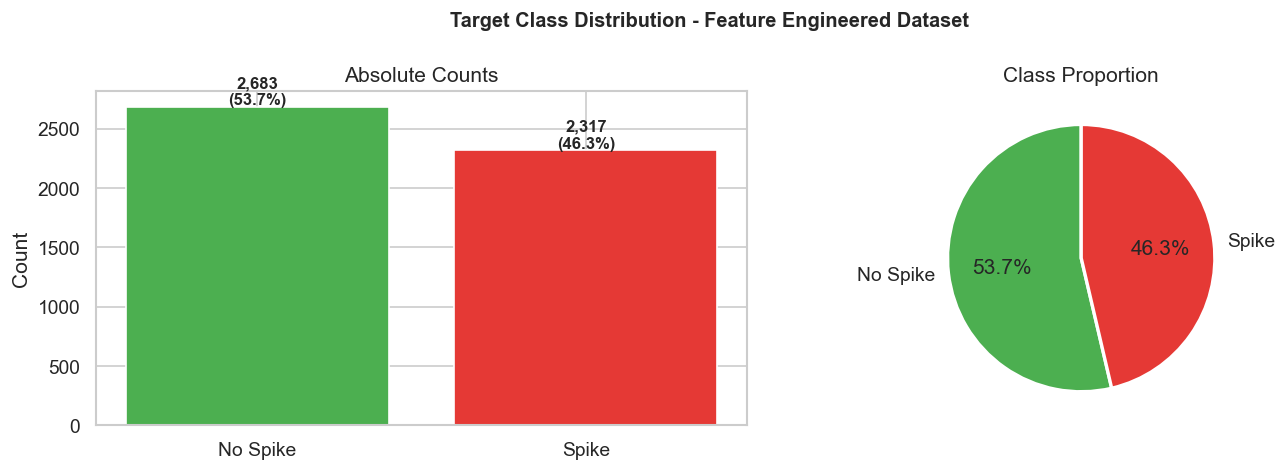

In [28]:
# just double-checking that the feature engineering did not accidentally shift the class ratio
spike_counts = dfe["glucose_spike"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Target Class Distribution - Feature Engineered Dataset", fontsize=12, fontweight="bold")

bars = axes[0].bar(["No Spike", "Spike"], spike_counts.values,
                   color=["#4CAF50", "#E53935"], edgecolor="white")
axes[0].set_title("Absolute Counts")
axes[0].set_ylabel("Count")
for i, val in enumerate(spike_counts.values):
    axes[0].text(i, val + 20, f"{val:,}\n({val/len(dfe)*100:.1f}%)",
                 ha="center", fontsize=10, fontweight="bold")

axes[1].pie(spike_counts.values, labels=["No Spike", "Spike"],
            colors=["#4CAF50", "#E53935"], autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.show()

## 5.8 Visualise Engineered Features

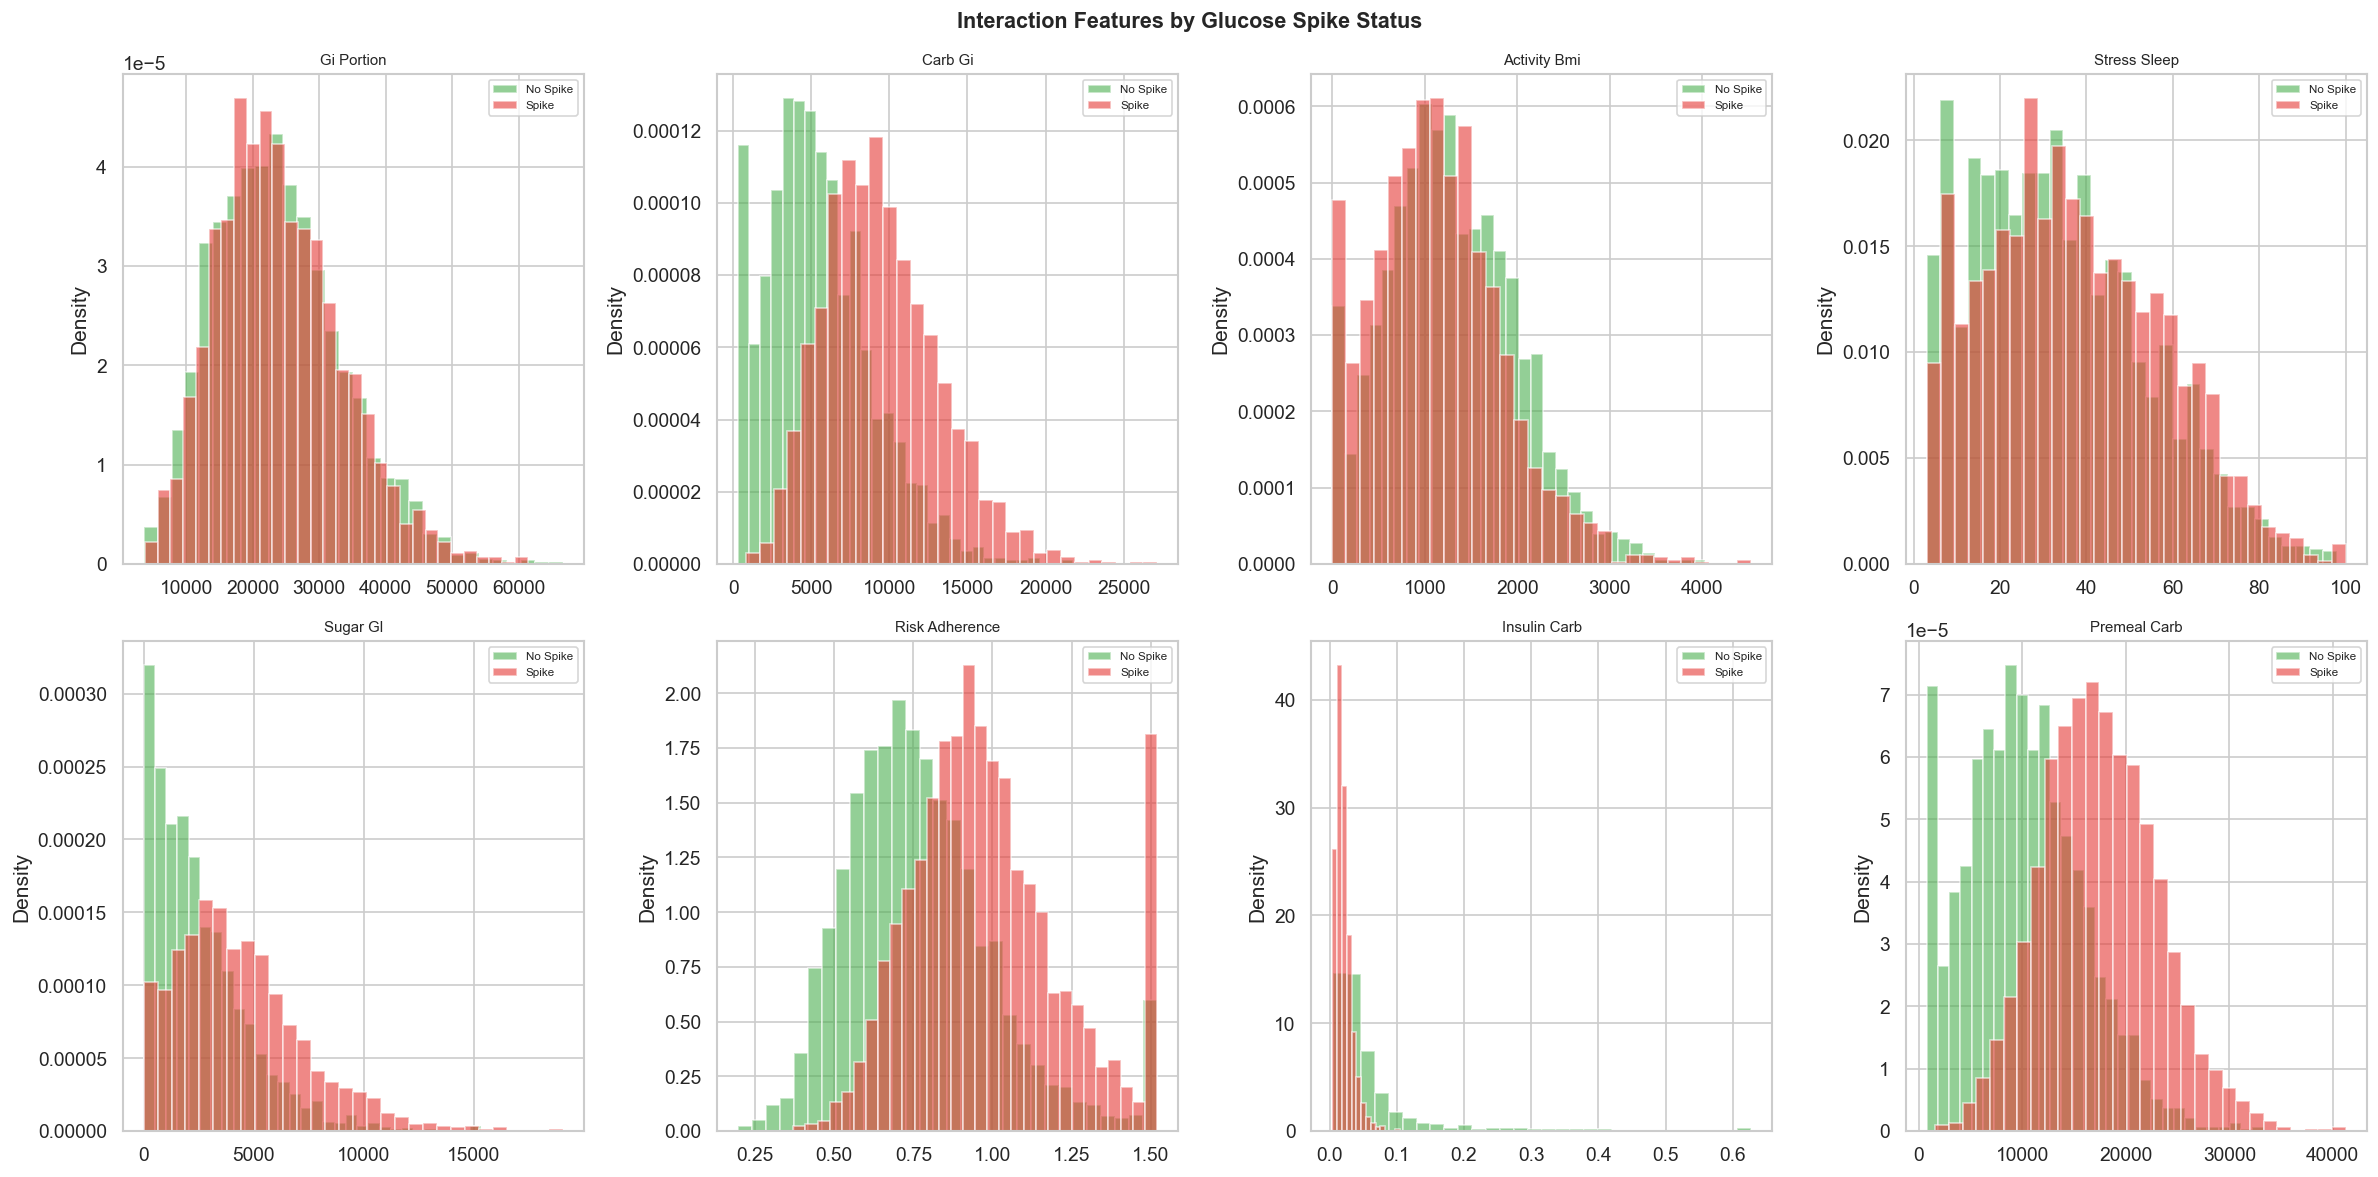

In [29]:
# overlapping density plots let us see which engineered features separate the two classes well
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle("Interaction Features by Glucose Spike Status", fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, interaction_cols):
    d0 = dfe[dfe["glucose_spike"] == 0][col].dropna()
    d1 = dfe[dfe["glucose_spike"] == 1][col].dropna()
    ax.hist(d0, bins=30, alpha=0.6, color="#4CAF50", label="No Spike",
            edgecolor="white", density=True)
    ax.hist(d1, bins=30, alpha=0.6, color="#E53935", label="Spike",
            edgecolor="white", density=True)
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.legend(fontsize=7)
    ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

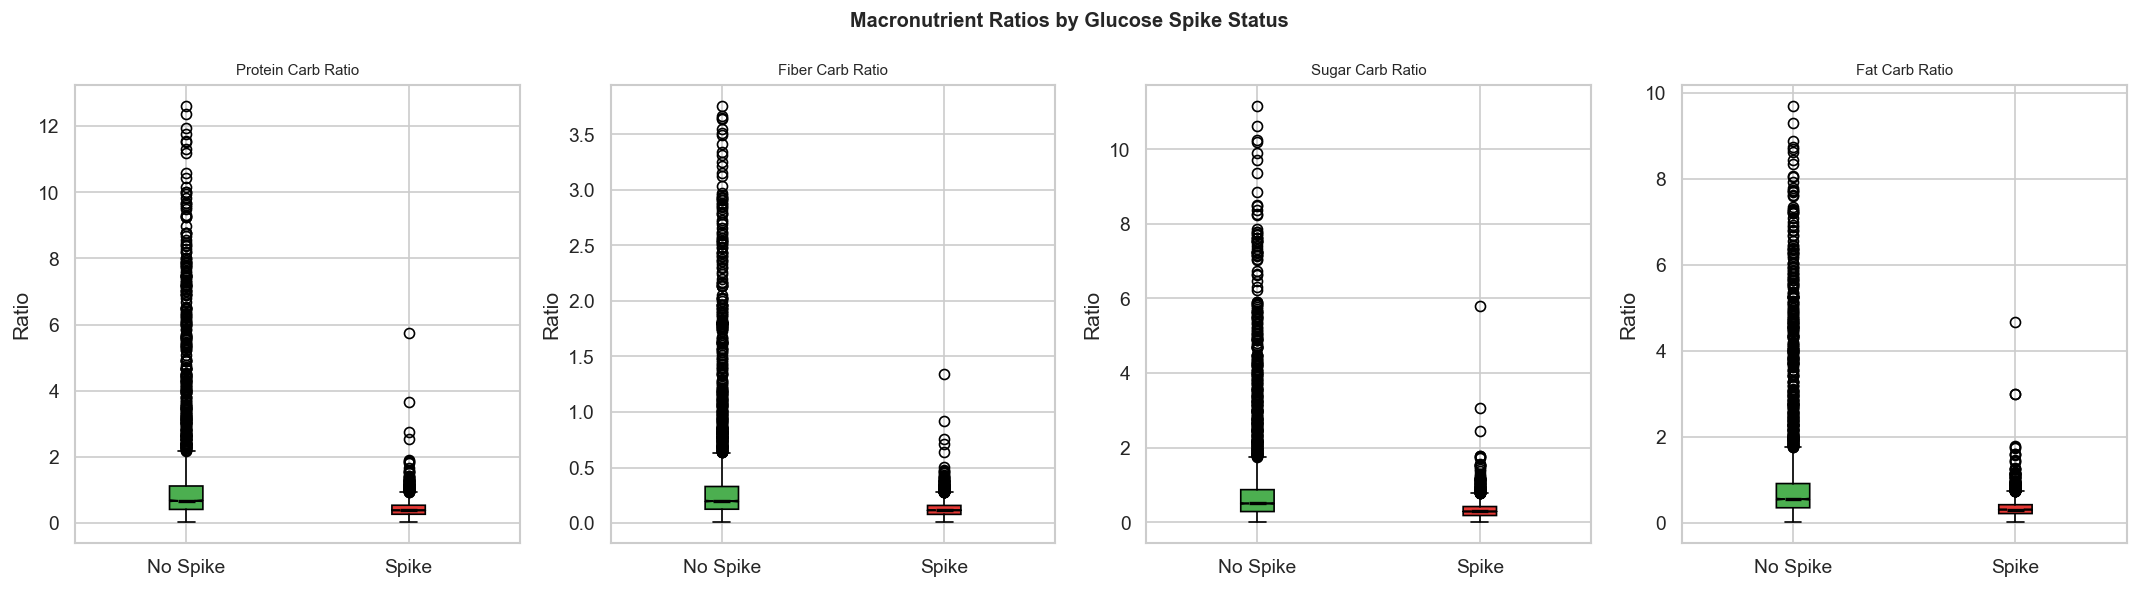

In [30]:
# notched boxplots — if the notches do not overlap, the medians are significantly different
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("Macronutrient Ratios by Glucose Spike Status", fontsize=12, fontweight="bold")

for ax, col in zip(axes, ["protein_carb_ratio", "fiber_carb_ratio",
                           "sugar_carb_ratio", "fat_carb_ratio"]):
    data = [dfe[dfe["glucose_spike"] == 0][col].dropna(),
            dfe[dfe["glucose_spike"] == 1][col].dropna()]
    bp = ax.boxplot(data, labels=["No Spike", "Spike"],
                    patch_artist=True, notch=True,
                    medianprops={"color": "black", "linewidth": 2})
    bp["boxes"][0].set_facecolor("#4CAF50")
    bp["boxes"][1].set_facecolor("#E53935")
    ax.set_title(col.replace("_", " ").title(), fontsize=9)
    ax.set_ylabel("Ratio")

plt.tight_layout()
plt.show()

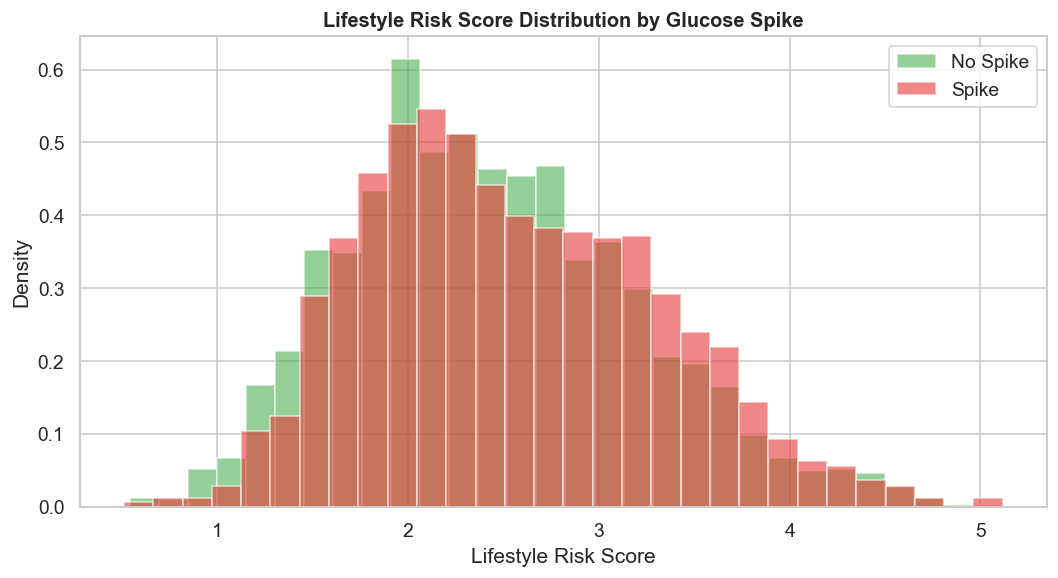

In [31]:
fig, ax = plt.subplots(figsize=(9, 5))
for spike_val, color, label in [(0, "#4CAF50", "No Spike"), (1, "#E53935", "Spike")]:
    ax.hist(dfe[dfe["glucose_spike"] == spike_val]["lifestyle_risk_score"],
            bins=30, alpha=0.6, color=color, label=label, edgecolor="white", density=True)
ax.set_title("Lifestyle Risk Score Distribution by Glucose Spike", fontsize=12, fontweight="bold")
ax.set_xlabel("Lifestyle Risk Score")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

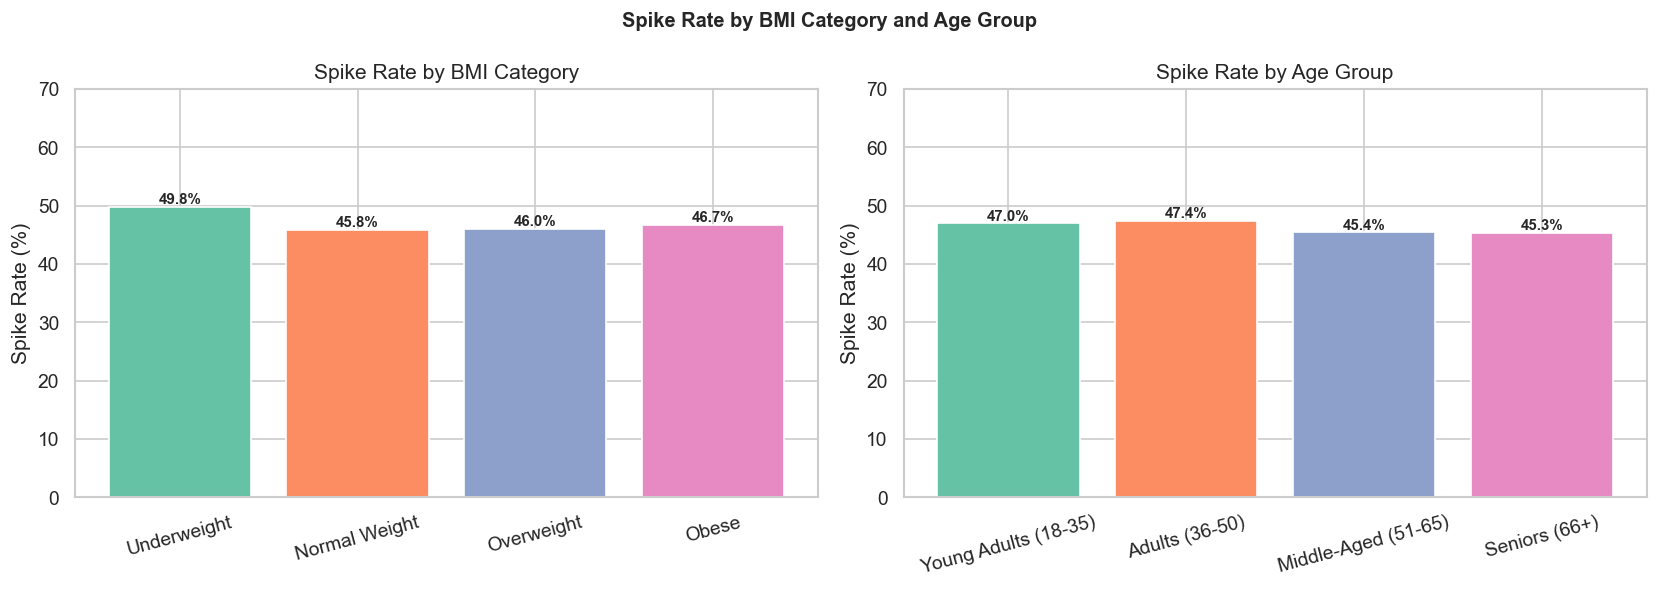

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Spike Rate by BMI Category and Age Group", fontsize=12, fontweight="bold")

for ax, col, title in [(axes[0], "bmi_category", "BMI Category"),
                       (axes[1], "age_group",     "Age Group")]:
    rates = (dfe.groupby(col, observed=True)["glucose_spike"]
               .mean().mul(100).reset_index())
    rates.columns = [col, "spike_rate"]
    bars = ax.bar(rates[col], rates["spike_rate"],
                  color=sns.color_palette("Set2", len(rates)), edgecolor="white")
    ax.set_title(f"Spike Rate by {title}")
    ax.set_ylabel("Spike Rate (%)")
    ax.set_ylim(0, 70)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, rates["spike_rate"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

In [33]:
import os
os.makedirs("data/processed", exist_ok=True)

# save the feature-engineered dataset for use in the next notebook
df_clean.to_csv("data/processed/glucose_spike_features.csv", index=False)
print("Saved: data/processed/glucose_spike_features.csv")
print(f"Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")

Saved: glucose_spike_feature_v2.csv
Final shape: 5,000 rows x 50 columns


## 6. Drop Unnecessary / Irrelevant Columns

To reduce noise and prevent data leakage.

In [34]:
# patient_id is just a row identifier. It doesn't add any signal to the dataset.
# post_meal_glucose and glucose_change are measured AFTER the spike happens,
# so the model cannot know them at prediction time which can cause data leakage
# carb_fiber_ratio is superseded by the cleaner fiber_carb_ratio we made in FE
# glycemic_load is largely captured by carb_gi already
cols_to_drop = [
    "patient_id",          # identifier, zero predictive value
    "post_meal_glucose",   # post-outcome — data leakage
    "glucose_change",      # derived from post - pre glucose — data leakage
    "carb_fiber_ratio",    # replaced by fiber_carb_ratio in feature engineering
    "glycemic_load",       # redundant with carb_gi interaction feature
]

df_clean = dfe.drop(columns=cols_to_drop)

print(f"Original shape : {dfe.shape}")
print(f"Dropped        : {len(cols_to_drop)} columns")
print(f"Remaining shape: {df_clean.shape}")

Original shape : (5000, 50)
Dropped        : 5 columns
Remaining shape: (5000, 45)


---
## 6. Drop Unnecessary / Irrelevant Columns
To reduce noise and prevent data leakage before modelling.

In [34]:
# patient_id is just a row identifier. It doesn't add any signal to the dataset.
# post_meal_glucose and glucose_change are measured AFTER the spike happens,
# so the model cannot know them at prediction time which can cause data leakage
# carb_fiber_ratio is superseded by the cleaner fiber_carb_ratio we made in FE
# glycemic_load is largely captured by carb_gi already
cols_to_drop = [
    "patient_id",          # identifier, zero predictive value
    "post_meal_glucose",   # post-outcome — data leakage
    "glucose_change",      # derived from post - pre glucose — data leakage
    "carb_fiber_ratio",    # replaced by fiber_carb_ratio in feature engineering
    "glycemic_load",       # redundant with carb_gi interaction feature
]

df_clean = dfe.drop(columns=cols_to_drop)

print(f"Original shape : {dfe.shape}")
print(f"Dropped        : {len(cols_to_drop)} columns")
print(f"Remaining shape: {df_clean.shape}")

Original shape : (5000, 50)
Dropped        : 5 columns
Remaining shape: (5000, 45)


---
## 7. Save Feature-Engineered Dataset

In [ ]:
import os
os.makedirs("data/processed", exist_ok=True)

df_clean.to_csv("data/processed/glucose_spike_features.csv", index=False)
print("Saved: data/processed/glucose_spike_features.csv")
print(f"Final shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"\nFeature summary:")
print(f"  Original features  : 28")
print(f"  Engineered features: 21")
print(f"  Dropped columns    : 5")
print(f"  Final features     : {df_clean.shape[1] - 1} (excluding target)")